In [1]:
import sys
from pyprojroot import here

# Ritorna il percorso assoluto della root del progetto
PROJECT_ROOT = str(here()) + "/"
sys.path.append(PROJECT_ROOT)
sys.dont_write_bytecode = True

print(f"La root del progetto è: {PROJECT_ROOT}")

La root del progetto è: /home/cvalentino/SissaUnisaDraftCodes/


In [2]:
from paths import DRT_PATH, TP5_PATH, MODEL_PATH, COLUMN_PATH

ABS_PATH = PROJECT_ROOT + DRT_PATH + TP5_PATH
LOAD_MODEL = PROJECT_ROOT + MODEL_PATH + COLUMN_PATH

model_name = "column.blend"
load_data_bound = ABS_PATH + "./files/data.csv"
load_collocation_points = ABS_PATH + "files/input_int.csv"

fig_dir = "figures/"
loss_fig = ABS_PATH + fig_dir + "loss_data.png"

file_path = "column.xdmf"

params_save = ABS_PATH + "files/pred_parameters.csv"
# Nome files
model_name_features = "./models/file"
model_saved_name = './models/model_weights'

In [3]:
# Import
import json
import torch
import pandas as pd
import fenics as fe
import matplotlib.pyplot as plt

from modelaquisition.msh2xdmf import Msh2Xdmf
from modelaquisition.bl2pina import Blend2Pina

from pina.operators import laplacian
from pina.condition import Condition
from pina.solvers.pinns import RBAPINN
from pina.problem import SpatialProblem
from pina.callbacks import MetricTracker
from pina.equation import SystemEquation
from pina.model import ResidualFeedForward
from pina import LabelTensor, Trainer, Plotter
from pytorch_lightning.callbacks import StochasticWeightAveraging

[michael-Alienware-Aurora-R15:49960] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.michael-Alienware-Aurora-R15.1001/jf.0/587268096/shared_mem_cuda_pool.michael-Alienware-Aurora-R15 could be created.
[michael-Alienware-Aurora-R15:49960] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 
/home/cvalentino/miniconda3/envs/dtsu/lib/python3.11/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [4]:
torch.set_default_dtype(torch.float64)
torch.set_float32_matmul_precision('high')

Consideriamo il problema sul dominio $\Omega$ di frontiera $\Gamma = \partial \Omega$
$$
\begin{equation}
    \begin{cases}
        \Delta u = & \left(
                \begin{matrix}
                    2 u_1\\
                    2
                \end{matrix}
            \right), & \left(x,y,z\right) \in \Omega \\
        u \left( x, y, z \right) = & \left(
                \begin{matrix}
                    e^{x+y}\\
                    x^2 - z
                \end{matrix} \right) & \left( x, y, z \right) \in \Gamma
    \end{cases}
    \tag{1}
\end{equation}
$$

di soluzione analitica $u : \Omega \subseteq \mathbb{R}^3 \longmapsto \mathbb{R}^2$
$$
\begin{equation}
    u \left( x, y, z \right) = \left(
                \begin{matrix}
                    e^{x+y}\\
                    x^2 - z
                \end{matrix} \right) \qquad \left( x, y, z \right) \in \Omega
    \tag{2}
\end{equation}
$$

In [5]:
# Carica la mesh da file XDMF
mesh = fe.Mesh()
with fe.XDMFFile(file_path) as infile:
    infile.read(mesh)

mesh_points = LabelTensor(
    mesh.coordinates(),
    labels=['x', 'y', 'z']
)

In [6]:
collocation_points = 1_000
boundary_points = 500

# Network variables
lear_rate = 5e-4
decay_rt = 1e-8

# Solver variables
epochs = 5_000
acc_str = 'gpu'
batch_dim = None
num_layers = 2
num_neurons = 200
input_neurons = 3
output_neurons = 2

# Acquisizione dominio e frontiera

In [7]:
filename = LOAD_MODEL + model_name
column = Blend2Pina(filename)

column_int = column.intern()
column_bound = column.boundary()

Read blend: "/home/cvalentino/SissaUnisaDraftCodes/models/column/column.blend"


In [8]:
df = pd.read_csv(load_data_bound, sep=";", index_col=0)

df = df.sample(boundary_points)
input_pts = df.iloc[:, :3].values
input_pts = LabelTensor(
    x=torch.tensor(input_pts, dtype=torch.float64),
    labels=['x', 'y', 'z']
)
output_pts = df.iloc[:, 3:].values
output_pts = LabelTensor(
    x=torch.reshape(torch.tensor(output_pts, dtype=torch.float64), (output_pts.shape[0], 2)),
    labels=['u1', 'u2']
)

## Definizione del problema

In [9]:
class Poisson(SpatialProblem):
    input_variables = ['x','y','z']
    output_variables = ['u1', 'u2']
    spatial_domain =column_int

    @staticmethod
    def eq1(input_, output_):
        delta_u = laplacian(output_, input_, components=['u1'], d=['x','y','z'])
        force_term = 2 * output_.extract('u1')
        return delta_u - force_term
    
    @staticmethod
    def eq2(input_, output_):
        delta_u = laplacian(output_, input_, components=['u2'], d=['x','y','z'])
        force_term = 2
        return delta_u - force_term
    
    conditions = {
        "Omega" : Condition(
            location=column_int,
            equation=SystemEquation([eq1, eq2])
        ),
        "Gamma" : Condition(
            input_points=input_pts,
            output_points=output_pts
        )
    }

problem = Poisson()

In [10]:
try:
    df = pd.read_csv(load_collocation_points, sep=";", index_col=0)
    problem.discretise_domain(
        1,
        locations=["Omega"]
    )
    problem.input_pts["Omega"] = LabelTensor(
        torch.tensor(df.sample(collocation_points).values),
        labels=['x', 'y', 'z']
    )

except:
    problem.discretise_domain(
        collocation_points,
        locations=["Omega"]
    )
    df = pd.DataFrame(
        problem.input_pts["Omega"].tensor.detach().numpy()
    )
    df.to_csv(load_collocation_points, sep = ";")

In [11]:
# Modello
model = ResidualFeedForward(input_dimensions=input_neurons,output_dimensions=output_neurons,n_layers=num_layers,inner_size=num_neurons)
# Solver
pinn=RBAPINN(
    problem=problem,
    model=model,
    optimizer_kwargs={
        'lr' : lear_rate,
        'weight_decay' : decay_rt
    },
)

# Trainer
trainer=Trainer(
    solver=pinn,
    max_epochs=epochs,
    batch_size=batch_dim,
    accelerator=acc_str,
    precision='64-true',
    callbacks=[MetricTracker(), StochasticWeightAveraging(swa_lrs=5e-4, swa_epoch_start=.9)]
)

# Addestramento
trainer.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


/home/cvalentino/miniconda3/envs/dtsu/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type    | Params | Mode 
----------------------------------------------------
0 | _loss           | MSELoss | 0      | train
1 | _neural_net     | Network | 43.0 K | train
2 | _vectorial_loss | MSELoss | 0      | train
----------------------------------------------------
43.0 K    Trainable params
0         Non-trainable params
43.0 K    Total params
0.172     Total estimated model

Epoch 4498: 100%|██████████| 2/2 [00:00<00:00, 96.42it/s, v_num=18, Omega_loss=0.000565, mean_loss=0.00137, Gamma_loss=0.00298]   

Swapping scheduler `ConstantLR` for `SWALR`


Epoch 4999: 100%|██████████| 2/2 [00:00<00:00, 97.03it/s, v_num=18, Omega_loss=0.000505, mean_loss=0.000358, Gamma_loss=6.57e-5]  

`Trainer.fit` stopped: `max_epochs=5000` reached.


Epoch 4999: 100%|██████████| 2/2 [00:00<00:00, 83.16it/s, v_num=18, Omega_loss=0.000505, mean_loss=0.000358, Gamma_loss=6.57e-5]


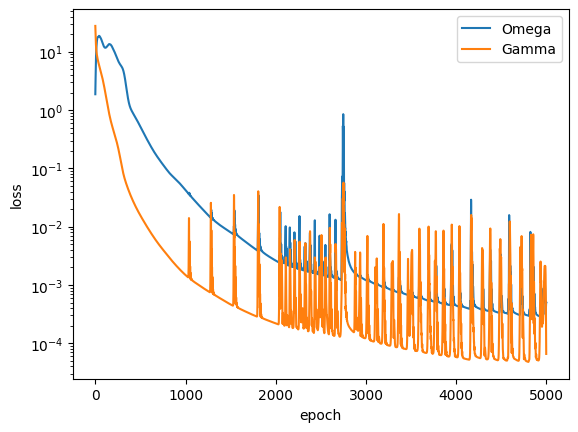

In [12]:
my_pl = Plotter()
my_pl.plot_loss(
    trainer=trainer,
    metrics=['Omega_loss'],
    label='Omega',
    logy=True
)
my_pl.plot_loss(
    trainer=trainer,
    metrics=['Gamma_loss'],
    label='Gamma',
    logy=True
)

plt.savefig(loss_fig, transparent=True)
plt.show()

In [13]:
def analytical(pts):
    u1 = torch.exp(pts.extract('x') + pts.extract('y'))
    u2 = pts.extract('x')**2 - pts.extract('z')
    sol = LabelTensor(
        torch.cat([u1, u2], axis=-1),
        labels=['u1', 'u2']
    )
    return sol

In [14]:
pred = pinn.neural_net(problem.input_pts["Omega"])
analit = analytical(problem.input_pts["Omega"])

err_matrix = LabelTensor(
    pred - analit.tensor,
    labels=['u1', 'u2']
)

In [15]:
# Errori assoluti
err_a_u1 = torch.norm(err_matrix.extract('u1'), p=2).tensor.item()
err_a_u2 = torch.norm(err_matrix.extract('u2'), p=2).tensor.item()

# Errori relativi
err_r_u1 = err_a_u1 / torch.norm(analit.extract('u1'), p=2).tensor.item()
err_r_u2 = err_a_u2 / torch.norm(analit.extract('u2'), p=2).tensor.item()

print("TRAINING POINTS")
print("ERRORI ASSOLUTI")
print(f"u_1 -> {err_a_u1:.4e}")
print(f"u_2 -> {err_a_u2:.4e}")
print("----------------------------")
print("ERRORI RELATIVI")
print(f"u_1 -> {err_r_u1:.4e}")
print(f"u_2 -> {err_r_u2:.4e}")

TRAINING POINTS
ERRORI ASSOLUTI
u_1 -> 2.9376e-01
u_2 -> 1.0836e-01
----------------------------
ERRORI RELATIVI
u_1 -> 4.4605e-03
u_2 -> 6.6060e-04


In [16]:
print("TOT ERROR")
err = torch.norm(pred.tensor - analit.tensor).item()
err_rel = err / torch.norm(analit.tensor).item()

print(f"Errore assoluto: {err:.4e}")
print(f"Errore relativo: {err_rel:.4e}")

TOT ERROR
Errore assoluto: 3.1311e-01
Errore relativo: 1.7713e-03


In [17]:
pred = pinn.neural_net(mesh_points)
analit = analytical(mesh_points)

err_matrix = LabelTensor(
    torch.abs(pred - analit.tensor),
    labels=['u1', 'u2']
)

In [18]:
# Errori assoluti
err_a_u1 = torch.norm(err_matrix.extract('u1'), p=2).tensor.item()
err_a_u2 = torch.norm(err_matrix.extract('u2'), p=2).tensor.item()

# Errori relativi
err_r_u1 = err_a_u1 / torch.norm(analit.extract('u1'), p=2).tensor.item()
err_r_u2 = err_a_u2 / torch.norm(analit.extract('u2'), p=2).tensor.item()

print("TESTING POINTS)")
print("ERRORI ASSOLUTI")
print(f"u_1 -> {err_a_u1:.4e}")
print(f"u_2 -> {err_a_u2:.4e}")
print("----------------------------")
print("ERRORI RELATIVI")
print(f"u_1 -> {err_r_u1:.4e}")
print(f"u_2 -> {err_r_u2:.4e}")

TESTING POINTS)
ERRORI ASSOLUTI
u_1 -> 2.6697e+00
u_2 -> 5.6542e-01
----------------------------
ERRORI RELATIVI
u_1 -> 7.4181e-03
u_2 -> 1.0097e-03


In [19]:
print("TOT ERROR TESTING")
err_t = torch.norm(pred.tensor - analit.tensor).item()
err_rel_t = err_t / torch.norm(analit.tensor).item()

print(f"Errore assoluto: {err_t:.4e}")
print(f"Errore relativo: {err_rel_t:.4e}")

TOT ERROR TESTING
Errore assoluto: 2.7289e+00
Errore relativo: 4.0997e-03


## Creazione visualizzazione

In [20]:
column_xdmf = Msh2Xdmf("column.msh", "column")

column_xdmf.reset_files("_data_sol_pinn")
column_xdmf.reset_files("_data_sol_an")
column_xdmf.reset_files("_data_err_r")

first_column = err_matrix.extract('u1') / torch.norm(analit.extract('u1').tensor, p=2).item()
second_column = err_matrix.extract('u2') / torch.norm(analit.extract('u2').tensor, p=2).item()

err_r_matrix = torch.cat([first_column, second_column], axis=-1)

column_xdmf.add_solution(pred.tensor.detach().numpy(), "_data_sol_pinn", "solution_pinn")
column_xdmf.add_solution(analit.tensor.detach().numpy(), "_data_sol_an", "solution_an")
column_xdmf.add_solution(err_r_matrix.detach().numpy(), "_data_err_r", "error")

File column_data_sol_pinn.xdmf cancellato.
File column_data_sol_pinn.h5 cancellato.
File column_data_sol_an.xdmf cancellato.
File column_data_sol_an.h5 cancellato.
File column_data_err_r.xdmf cancellato.
File column_data_err_r.h5 cancellato.


In [21]:
torch.save(model.state_dict(), model_saved_name + "_data" + '.pth')


In [22]:
create_model = {
    'num_hidden_layers' : num_layers,
    'num_hidden_neurons' : num_neurons,
    'input_dim' : input_neurons,
    'output_dim' : output_neurons
}

with open(model_name_features + "_data" + '.json', 'w') as file:
    json.dump(create_model, file, indent=4)